# Viscosity Pipeline Usage Example

This notebook shows how to run the reusable viscosity pipeline on:
'37kcP_reproducibility_20260525_091234.csv'
Workflow covered:
1. Load dataset
2. Normalize x-axis by cell
3. Trim before-hit and after-contact zones
4. Fit Polynomial(2nd) and Hyperbola
5. Map known real viscosities (user input)
6. Extrapolate unknown viscosities
7. Plot fits and accuracy

In [1]:
import sys
from pathlib import Path

def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "viscometry").is_dir():
            return p
    raise RuntimeError("Could not locate repo root (expected src/viscometry)")

PROJECT_ROOT = _find_repo_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

AUTO_RUNS = PROJECT_ROOT / "results" / "auto_runs"
AUTO_RUNS_LEGACY = PROJECT_ROOT / "results" / "Auto-runs"
ARCHIVE = PROJECT_ROOT / "results" / "runs" / "archive"

from pathlib import Path
import sys

import pandas as pd

# Locate helper module robustly across common notebook working directories.
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / 'results' / 'Auto-runs',
    Path.cwd().parent,
]
if helper_dir is None:
from viscometry.analysis.viscosity_pipeline import run_viscosity_pipeline

In [2]:
# Dataset to analyze
csv_filename = '37kcP_reproducibility_20260525_091234.csv'
csv_candidates = [
    Path.cwd() / csv_filename,
    Path.cwd() / 'results' / 'Auto-runs' / csv_filename,
    helper_dir / csv_filename,
    helper_dir.parent / 'results' / 'Auto-runs' / csv_filename,
]
csv_path_obj = next((path for path in csv_candidates if path.exists()), None)
if csv_path_obj is None:
    raise FileNotFoundError(f'CSV file not found: {csv_filename}')
csv_path = str(csv_path_obj)

# USER INPUT: known calibration viscosities in cP.
# Keep only cells you trust for calibration. Unknown cells can be omitted.

#real_viscosity_map = {
#    1: 11860,
#    2: 11860,
#    3: 11860,
#    4: 11860,
#    5: 11860,
#    6: 11860,
#    7: 11860,
#    8: 11860,
#    9: 11860,
#    10: 11860,
#    11: 11860,
#    12: 11860,
#    13: 11860,
#    14: 11860,
#    15: 11860,
#    16: 11860,
#    17: 11860,
#    18: 11860
#}

real_viscosity_map = {
     1: 37020,
     2: 37020,
     3: 37020,
     4: 37020,
     5: 37020,
     6: 37020,
     7: 37020,
     8: 37020,
     9: 37020,
     10: 37020,
     11: 37020,
     12: 37020,
     13: 37020,
     14: 37020,
     15: 37020,
     16: 37020,
     17: 37020,
     18: 37020,
  }

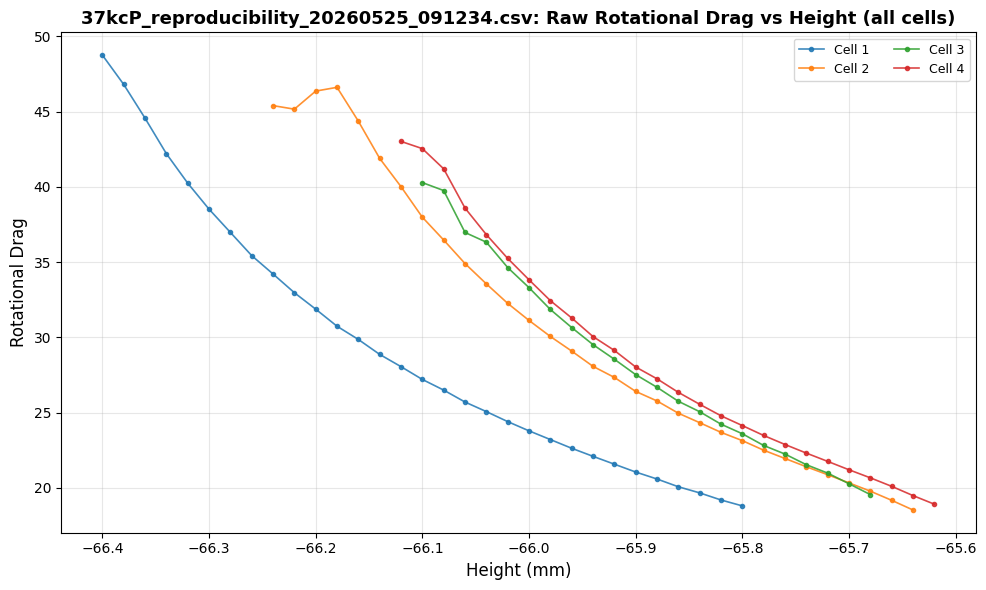

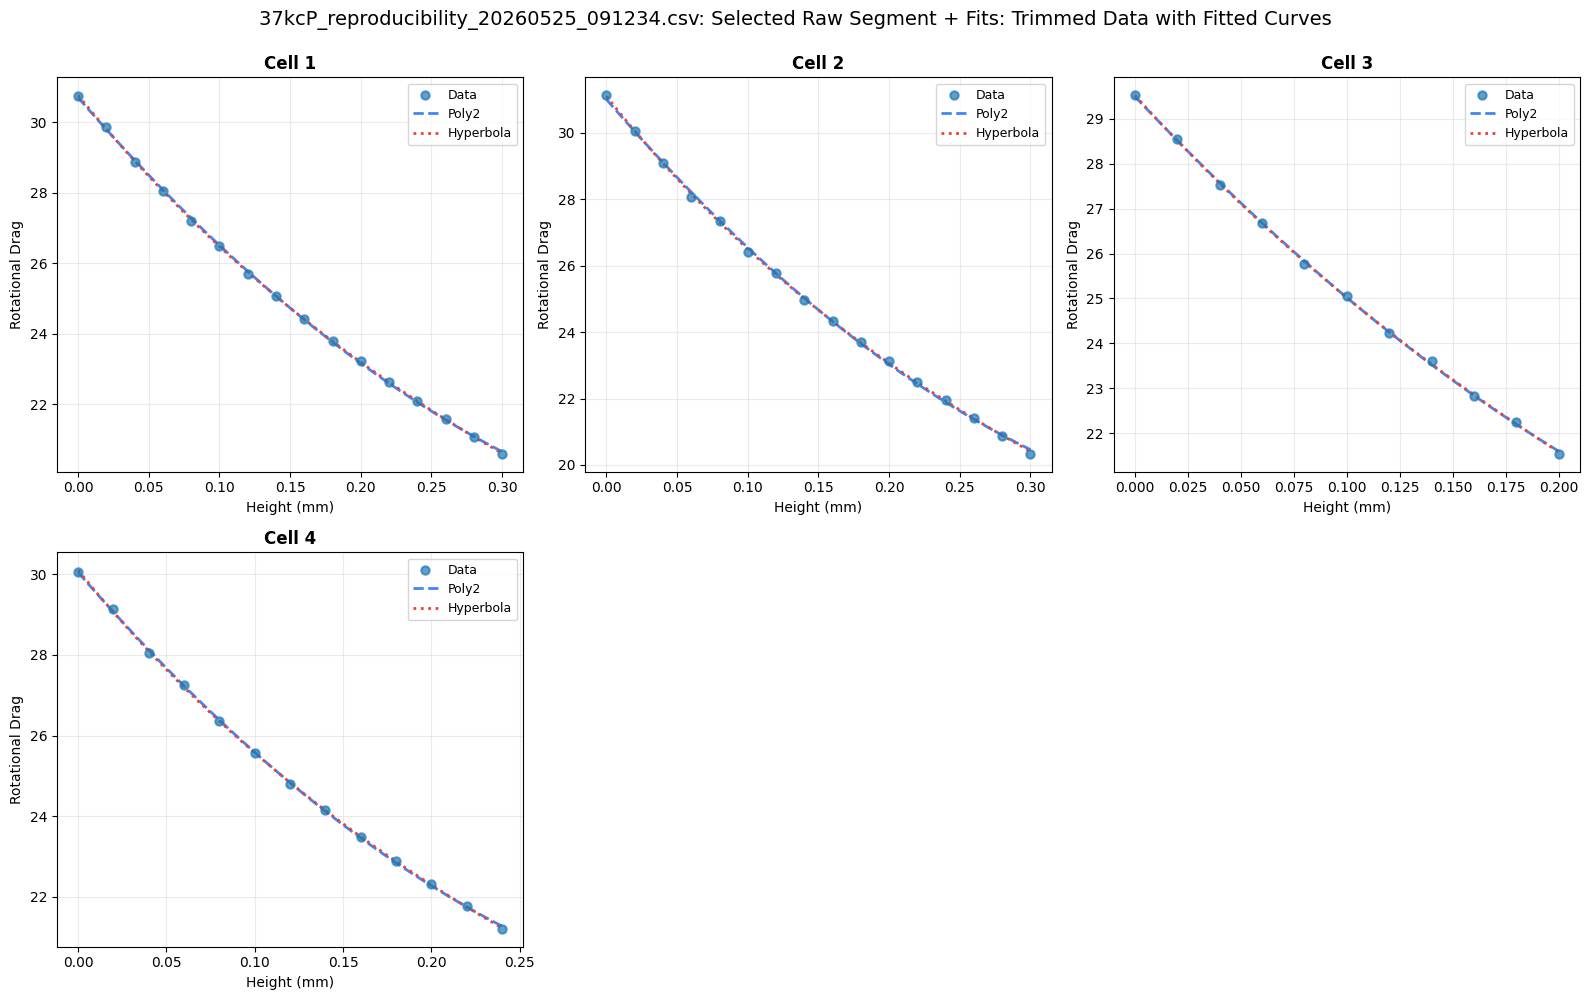

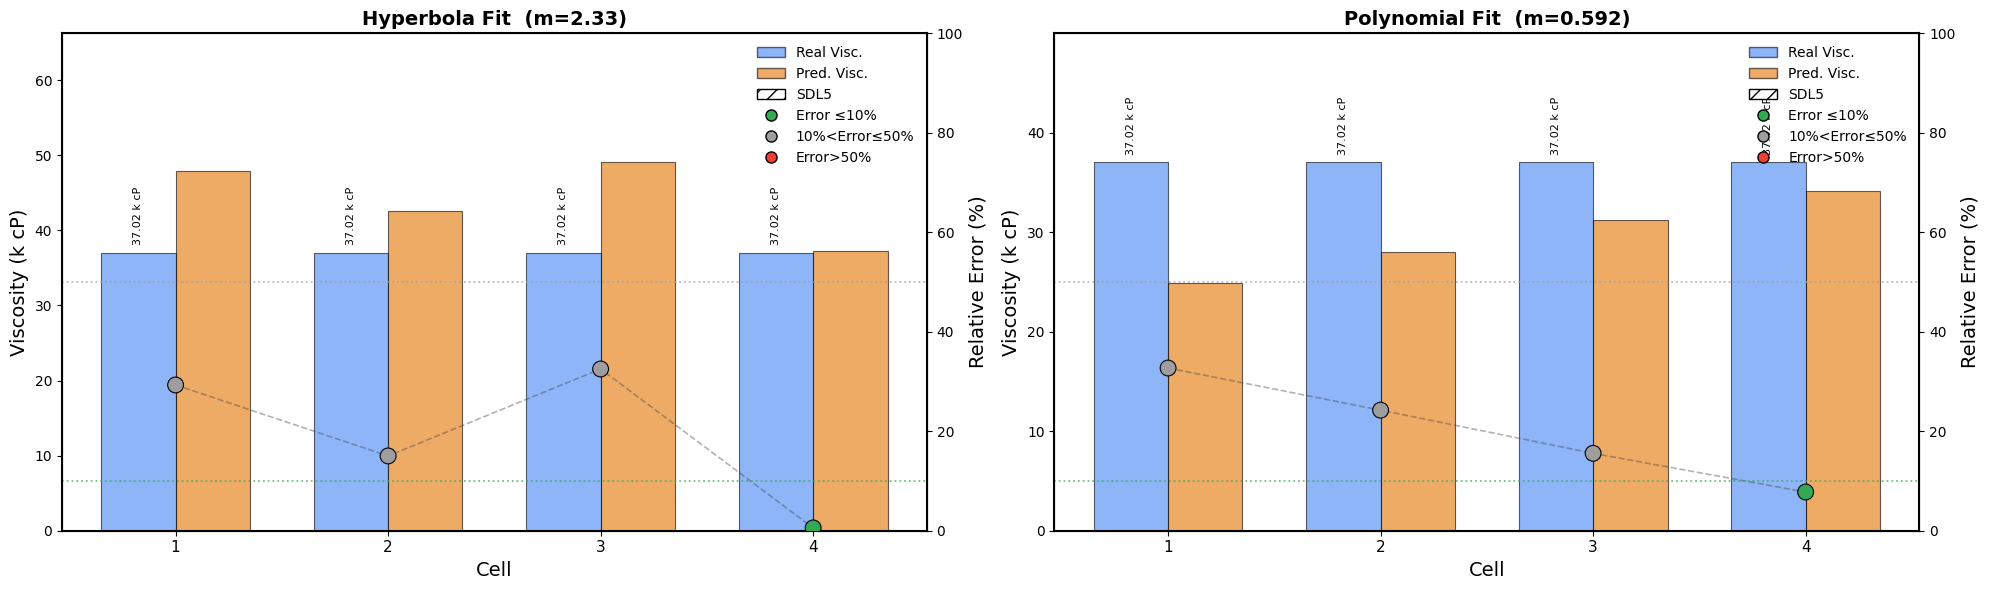

Learned scaling factors: {'poly': 0.592, 'hyperbola': 2.33}


In [3]:
pipeline_out = run_viscosity_pipeline(
    csv_path=csv_path,
    real_viscosity_map=real_viscosity_map,
    visualize=True,
)

print('Learned scaling factors:', pipeline_out['scales'])

In [4]:
pred_cols = [
    'cell',
    'a_poly2',
    'a_hyperbola',
    'real_viscosity',
    'predicted_visc_pol',
    'predicted_visc_hyp',
    'rel_error_pol',
    'rel_error_hyp',
    'is_calibration',
]

pred_df = pipeline_out['predictions'][pred_cols].sort_values('cell').reset_index(drop=True)
display(pred_df)

# Optional: save the predictions table
# pred_df.to_csv('viscosity_predictions_dynamic_analysis_L60kcP.csv', index=False)

,cell,a_poly2,a_hyperbola,real_viscosity,predicted_visc_pol,predicted_visc_hyp,rel_error_pol,rel_error_hyp,is_calibration
0,1,42.079325,20.544224,37020,24.910960,47.868041,32.709454,29.303191,True
1,2,47.378318,18.276990,37020,28.047964,42.585387,24.235645,15.033460,True
2,3,52.801378,21.054561,37020,31.258416,49.057128,15.563436,32.515203,True
3,4,57.665564,15.979011,37020,34.138014,37.231095,7.784943,0.570218,True
